# Parametric Drive T1 Analysis

This notebook reads and visualizes the parametric drive T1 data from the .h5 file.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Set plotting style
# plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 8)

In [3]:
from qcat.parser.qm_reader import load_xarray_h5, repetition_data
from qcat.utilities.simple_visualization import plot_2d_colormap_from_h5


In [4]:
# Define the path to the h5 file
h5_file_path = r'/Users/jacky/Library/CloudStorage/SynologyDrive-LCH_AS/data/EP/Parametric_drive/QtoR/20260210_tomo/x180/#1521_LCH_qubit_parametric_drive_time_tomo_13_004732/ds_raw.h5'

# Check if file exists
if os.path.exists(h5_file_path):
    print(f"Found h5 file: {h5_file_path}")
else:
    print(f"File not found: {h5_file_path}")
    print(f"Current directory: {os.getcwd()}")
    print("Available files in current directory:")
    for file in os.listdir('.'):
        if file.endswith('.h5'):
            print(f"  - {file}")

Found h5 file: /Users/jacky/Library/CloudStorage/SynologyDrive-LCH_AS/data/EP/Parametric_drive/QtoR/20260210_tomo/x180/#1521_LCH_qubit_parametric_drive_time_tomo_13_004732/ds_raw.h5


In [5]:
# Load data using the qcat parser
try:
    ds = load_xarray_h5(h5_file_path)
    print(f"Successfully loaded dataset with dimensions: {dict(ds.dims)}")
    print(f"Coordinates: {list(ds.coords.keys())}")
    print(f"Data variables: {list(ds.data_vars.keys())}")
    
    # Check if it has multiple qubits/repetitions
    if 'qubit' in ds.dims:
        print(f"\nFound {ds.sizes['qubit']} qubits in the dataset")
        qubit_data = repetition_data(ds, repetition_dim="qubit")
        print(f"Separated data into {len(qubit_data)} individual qubit datasets")
    else:
        qubit_data = [ds]  # Single dataset
        print("Single dataset (no qubit dimension)")
        
except Exception as e:
    print(f"Error loading file: {e}")
    ds = None

Successfully loaded dataset with dimensions: {'driving_time': 150, 'driving_frequency': 11, 'basis': 3, 'qubit': 1}
Coordinates: ['driving_time', 'driving_frequency', 'basis', 'qubit']
Data variables: ['state']

Found 1 qubits in the dataset
Separated data into 1 individual qubit datasets


/var/folders/gj/5g2p36y973q8qh7rskmqbpp00000gn/T/ipykernel_2387/4109142183.py:4: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Successfully loaded dataset with dimensions: {dict(ds.dims)}")


Creating heatmaps...
Selected basis index 2 from coordinate

Processing qubit 0: q1
Available data variables: ['state']
Available coordinates: ['driving_time', 'driving_frequency', 'basis']
Plotting: state vs driving_time, driving_frequency


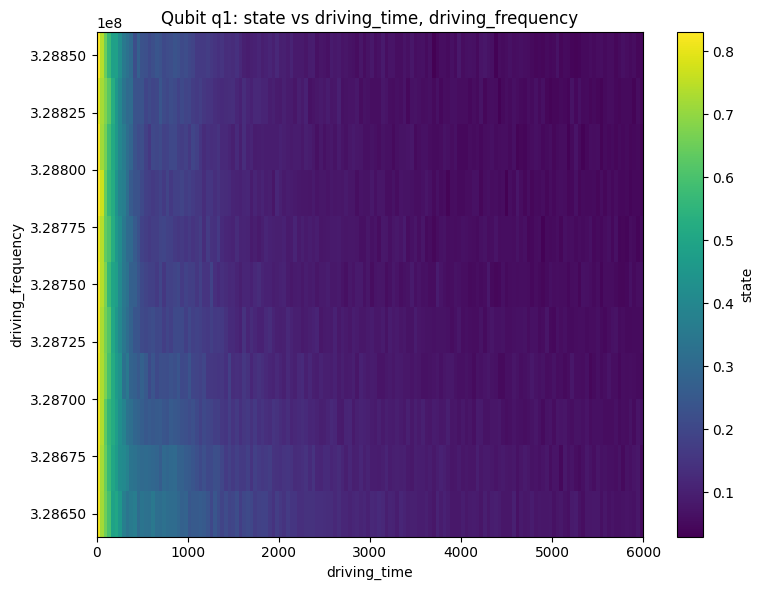


Heatmap creation complete!


In [7]:
# Analyze dataset structure and create heatmaps
if ds is not None and 'qubit_data' in locals():
    print("Creating heatmaps...")
    
    for i, sq_data in enumerate(qubit_data):
        # Select index 2 from basis coordinate if it exists
        if 'basis' in sq_data.coords:
            sq_data = sq_data.isel(basis=2)
            print(f"Selected basis index 2 from coordinate")
        
        try:
            qubit_name = sq_data["qubit"].values.item() if "qubit" in sq_data else f"Dataset_{i}"
            print(f"\nProcessing qubit {i}: {qubit_name}")
        except:
            print(f"\nProcessing dataset {i}")
            
        # Get available data variables and coordinates
        data_vars = list(sq_data.data_vars.keys())
        coords = [c for c in sq_data.coords.keys() if c != 'qubit']  # Exclude qubit coordinate
        
        print(f"Available data variables: {data_vars}")
        print(f"Available coordinates: {coords}")
        
        # User-specified plotting parameters
        x_dim = "driving_time"
        y_dim = "driving_frequency"
        data_var = "state"  # Specify your data variable here
        
        print(f"Plotting: {data_var} vs {x_dim}, {y_dim}")
        fig = plot_2d_colormap_from_h5(sq_data, data_var, x_dim, y_dim)
        if fig:
            plt.show()
    
    print("\nHeatmap creation complete!")

Creating 1D line plots (state vs driving_frequency)...
Selected basis index 2 from coordinate

Processing qubit 0: q1
Plotted time: 380.0 ns (requested: 400.0 ns)
Plotted time: 500.0 ns (requested: 500.0 ns)
Plotted time: 580.0 ns (requested: 600.0 ns)
Plotted time: 700.0 ns (requested: 700.0 ns)
Plotted time: 780.0 ns (requested: 800.0 ns)
Plotted time: 900.0 ns (requested: 900.0 ns)
Plotted time: 980.0 ns (requested: 1000.0 ns)
Plotted time: 1100.0 ns (requested: 1100.0 ns)
Plotted time: 1180.0 ns (requested: 1200.0 ns)
Plotted time: 1300.0 ns (requested: 1300.0 ns)
Plotted time: 1380.0 ns (requested: 1400.0 ns)
Target times average: calculated from 11 time points
All times average: calculated from 150 time points


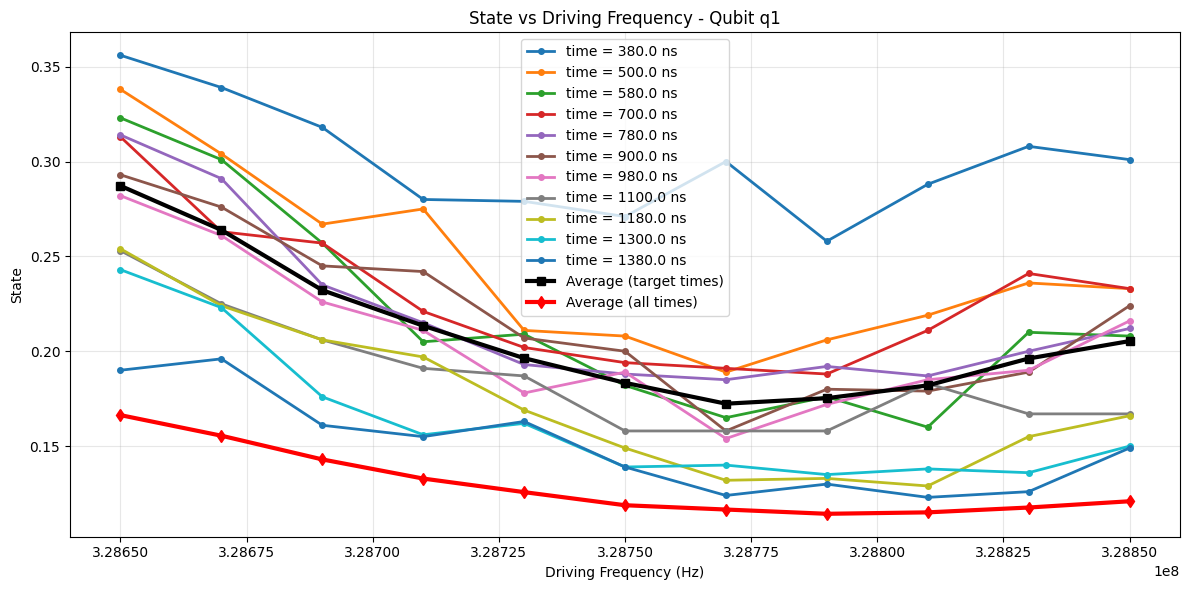


1D line plot (frequency sweep) creation complete!


In [8]:
# Plot 1D line graphs for specific driving times
if ds is not None and 'qubit_data' in locals():
    print("Creating 1D line plots (state vs driving_frequency)...")
    
    # User-specified driving times to plot
    target_times = [400,500,600,700,800,900,1000,1100,1200,1300,1400]  # Modify this list as needed (in ns)
    
    for i, sq_data in enumerate(qubit_data):
        # Select index 2 from basis coordinate if it exists
        if 'basis' in sq_data.coords:
            sq_data = sq_data.isel(basis=2)
            print(f"Selected basis index 2 from coordinate")
        
        try:
            qubit_name = sq_data["qubit"].values.item() if "qubit" in sq_data else f"Dataset_{i}"
            print(f"\nProcessing qubit {i}: {qubit_name}")
        except:
            print(f"\nProcessing dataset {i}")
        
        # Create figure for line plots
        plt.figure(figsize=(12, 6))
        
        # Get driving_time and driving_frequency arrays
        driving_time = sq_data.coords["driving_time"].values
        driving_freq = sq_data.coords["driving_frequency"].values
        
        # Collect state_data arrays for averaging
        state_data_arrays = []
        
        # Plot line for each target time
        for time in target_times:
            # Find closest time in the data
            time_idx = np.argmin(np.abs(driving_time - time))
            actual_time = driving_time[time_idx]
            
            # Extract state data for this time
            state_data = sq_data["state"].isel(driving_time=time_idx).values
            state_data_arrays.append(state_data)
            
            # Plot the line
            plt.plot(driving_freq, state_data, 'o-', label=f'time = {actual_time:.1f} ns', linewidth=2, markersize=4)
            print(f"Plotted time: {actual_time:.1f} ns (requested: {time:.1f} ns)")
        
        # Calculate average state_data from target times (existing method)
        avg_state_data_target = np.mean(state_data_arrays, axis=0)
        
        # Calculate average state_data across all driving times (new method)
        avg_state_data_all_time = sq_data["state"].mean(dim="driving_time").values
        
        # Plot both averages
        plt.plot(driving_freq, avg_state_data_target, 's-', label='Average (target times)', linewidth=3, markersize=6, color='black')
        plt.plot(driving_freq, avg_state_data_all_time, 'd-', label='Average (all times)', linewidth=3, markersize=6, color='red')
        
        print(f"Target times average: calculated from {len(target_times)} time points")
        print(f"All times average: calculated from {len(driving_time)} time points")
        
        # Format the plot
        plt.xlabel('Driving Frequency (Hz)')
        plt.ylabel('State')
        plt.title(f'State vs Driving Frequency - Qubit {qubit_name}')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    
    print("\n1D line plot (frequency sweep) creation complete!")

Creating 1D line plots...
Selected basis index 2 from coordinate

Processing qubit 0: q1
Plotted frequency: 328650000.000 GHz (requested: 315150000.000 GHz)


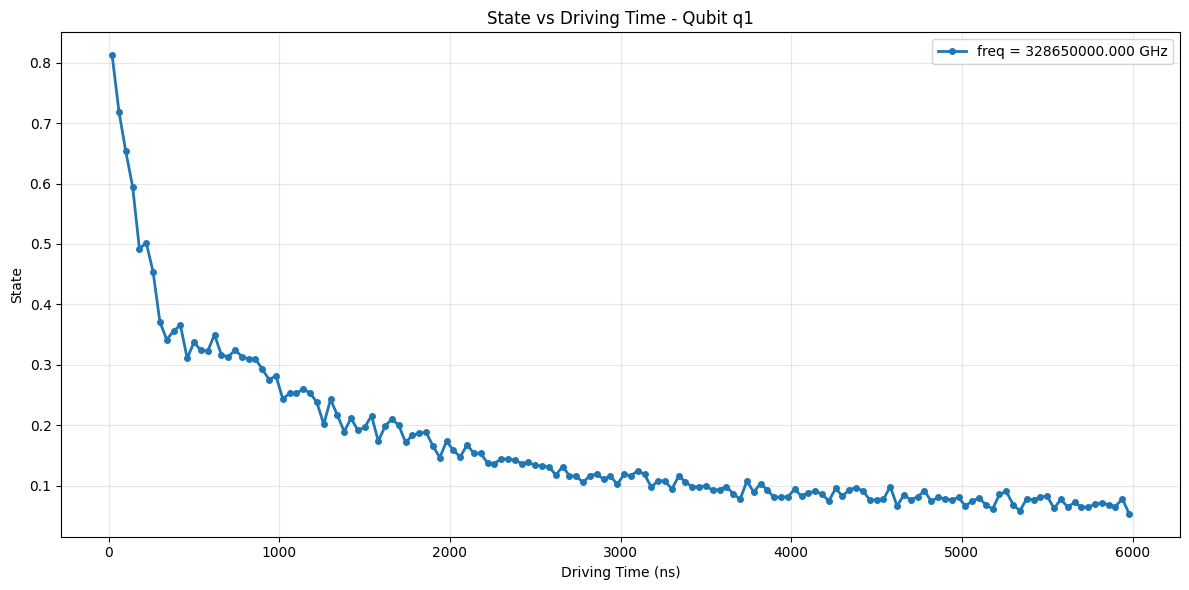


1D line plot creation complete!


In [9]:
# Plot 1D line graphs for specific driving frequencies
if ds is not None and 'qubit_data' in locals():
    print("Creating 1D line plots...")
    
    # User-specified driving frequencies to plot
    target_frequencies = [3.1515e8]  # Modify this list as needed
    
    for i, sq_data in enumerate(qubit_data):
        # Select index 2 from basis coordinate if it exists
        if 'basis' in sq_data.coords:
            sq_data = sq_data.isel(basis=2)
            print(f"Selected basis index 2 from coordinate")
        
        try:
            qubit_name = sq_data["qubit"].values.item() if "qubit" in sq_data else f"Dataset_{i}"
            print(f"\nProcessing qubit {i}: {qubit_name}")
        except:
            print(f"\nProcessing dataset {i}")
        
        # Create figure for line plots
        plt.figure(figsize=(12, 6))
        
        # Get driving_time and driving_frequency arrays
        driving_time = sq_data.coords["driving_time"].values
        driving_freq = sq_data.coords["driving_frequency"].values
        
        # Plot line for each target frequency
        for freq in target_frequencies:
            # Find closest frequency in the data
            freq_idx = np.argmin(np.abs(driving_freq - freq))
            actual_freq = driving_freq[freq_idx]
            
            # Extract state data for this frequency
            state_data = sq_data["state"].isel(driving_frequency=freq_idx).values
            
            # Plot the line
            plt.plot(driving_time, state_data, 'o-', label=f'freq = {actual_freq:.3f} GHz', linewidth=2, markersize=4)
            print(f"Plotted frequency: {actual_freq:.3f} GHz (requested: {freq:.3f} GHz)")
        
        # Format the plot
        plt.xlabel('Driving Time (ns)')
        plt.ylabel('State')
        plt.title(f'State vs Driving Time - Qubit {qubit_name}')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    
    print("\n1D line plot creation complete!")

Performing T1 exponential decay fitting...
Selected basis index 2 from coordinate

Analyzing qubit 0: q1
Frequency: 3.288 GHz
  T1 (τ): 468.2 ns
  Amplitude: 0.6759
  Offset: 0.0682
  R²: 0.9429


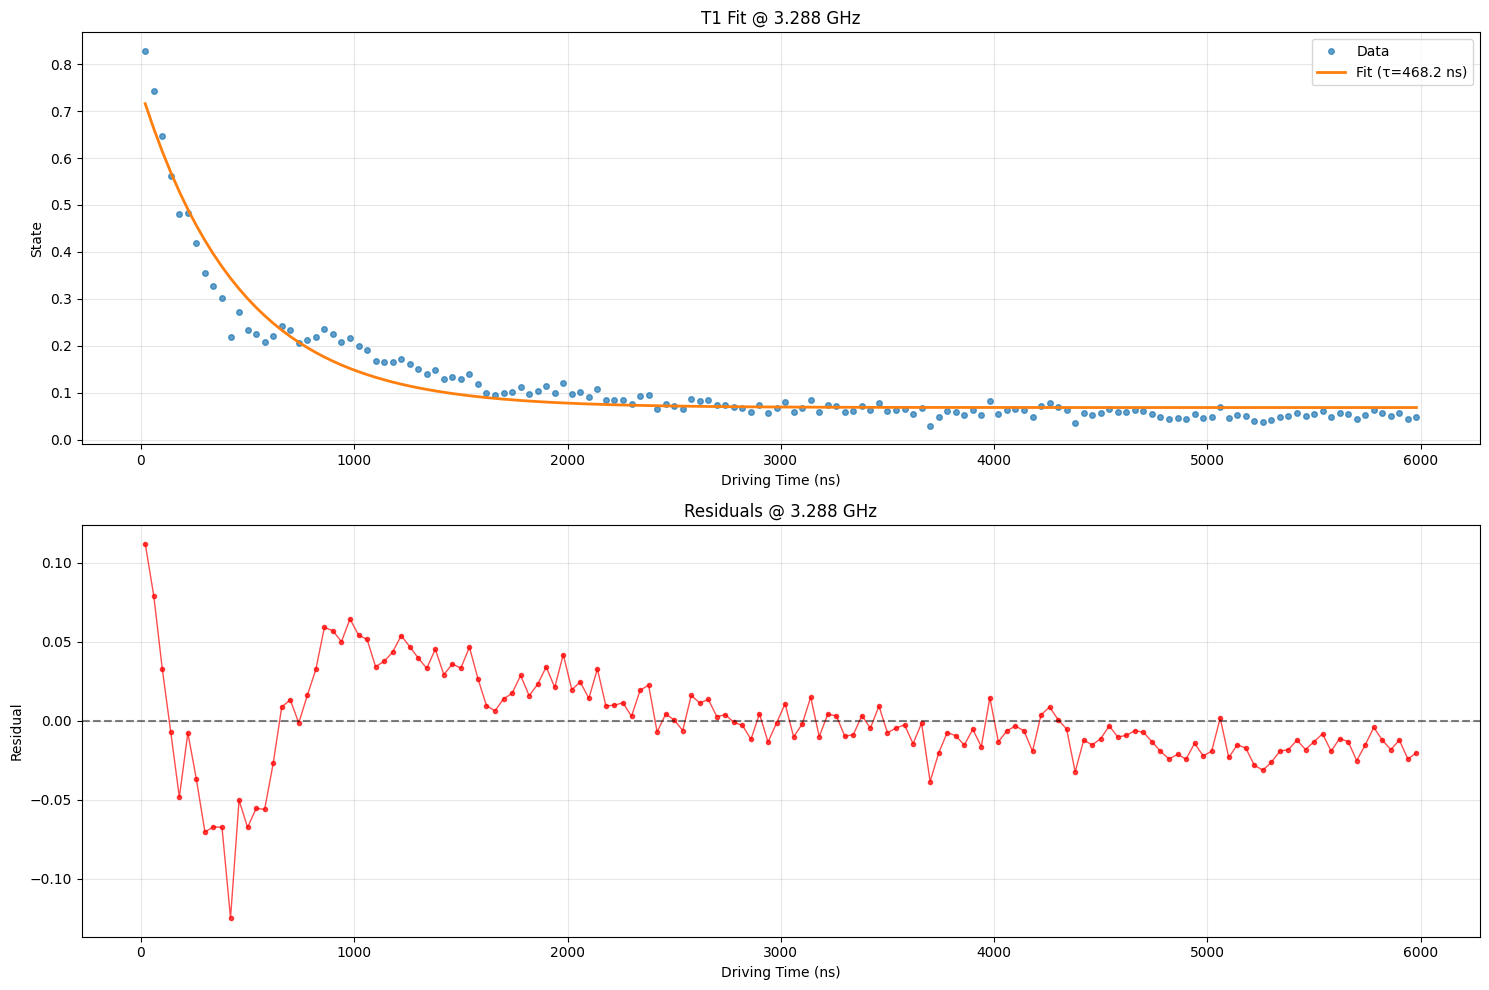


T1 Summary for Qubit q1:
Frequency (GHz) | T1 (ns) | R²
-----------------------------------
      3.288 |   468.2 | 0.9429

T1 fitting analysis complete!


In [10]:
# T1 fitting using exponential decay
import xarray as xr
from qcat.utilities.function_fitting.fit_exp_decay import FitExponentialDecay

if ds is not None and 'qubit_data' in locals():
    print("Performing T1 exponential decay fitting...")
    
    # User-specified driving frequencies for T1 analysis
    target_frequencies = [3.3826e8]  # Modify this list as needed
    
    for i, sq_data in enumerate(qubit_data):
        # Select index 2 from basis coordinate if it exists
        if 'basis' in sq_data.coords:
            sq_data = sq_data.isel(basis=2)
            print(f"Selected basis index 2 from coordinate")
        
        try:
            qubit_name = sq_data["qubit"].values.item() if "qubit" in sq_data else f"Dataset_{i}"
            print(f"\nAnalyzing qubit {i}: {qubit_name}")
        except:
            print(f"\nAnalyzing dataset {i}")
        
        # Get driving_time and driving_frequency arrays
        driving_time = sq_data.coords["driving_time"].values
        driving_freq = sq_data.coords["driving_frequency"].values
        
        # Create subplot for fitted curves and residuals
        plt.figure(figsize=(15, 10))
        
        # Results storage
        fit_results = []
        
        # Fit exponential decay for each target frequency
        for j, freq in enumerate(target_frequencies):
            # Top subplot for fit
            plt.subplot(2, len(target_frequencies), j+1)
            
            # Find closest frequency in the data
            freq_idx = np.argmin(np.abs(driving_freq - freq))
            actual_freq = driving_freq[freq_idx]
            
            # Extract state data for this frequency
            state_data = sq_data["state"].isel(driving_frequency=freq_idx).values
            
            # Create DataArray for fitting (fitter expects "x" coordinate)
            fit_data = xr.DataArray(
                state_data,
                coords={"x": driving_time},
                dims=["x"]
            )
            
            # Perform fitting
            fitter = FitExponentialDecay(fit_data)
            result = fitter.fit()
            
            # Extract fitted parameters
            a = result.params['a'].value
            tau = result.params['tau'].value
            c = result.params['c'].value
            
            # Store results
            fit_results.append({
                'frequency': actual_freq,
                'amplitude': a,
                'tau': tau,
                'offset': c,
                'r_squared': 1 - result.residual.var() / np.var(state_data)
            })
            
            # Plot data and fit
            plt.plot(driving_time, state_data, 'o', alpha=0.7, label='Data', markersize=4)
            plt.plot(driving_time, result.best_fit, '-', linewidth=2, label=f'Fit (τ={tau:.1f} ns)')
            
            plt.xlabel('Driving Time (ns)')
            plt.ylabel('State')
            plt.title(f'T1 Fit @ {actual_freq/1e8:.3f} GHz')
            plt.legend()
            plt.grid(True, alpha=0.3)
            
            # Bottom subplot for residuals
            plt.subplot(2, len(target_frequencies), j+1+len(target_frequencies))
            plt.plot(driving_time, result.residual, 'o-', color='red', alpha=0.7, markersize=3, linewidth=1)
            plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
            plt.xlabel('Driving Time (ns)')
            plt.ylabel('Residual')
            plt.title(f'Residuals @ {actual_freq/1e8:.3f} GHz')
            plt.grid(True, alpha=0.3)
            
            print(f"Frequency: {actual_freq/1e8:.3f} GHz")
            print(f"  T1 (τ): {tau:.1f} ns")
            print(f"  Amplitude: {a:.4f}")
            print(f"  Offset: {c:.4f}")
            print(f"  R²: {1 - result.residual.var() / np.var(state_data):.4f}")
        
        plt.tight_layout()
        plt.show()
        
        # Summary table
        print(f"\nT1 Summary for Qubit {qubit_name}:")
        print("Frequency (GHz) | T1 (ns) | R²")
        print("-" * 35)
        for res in fit_results:
            print(f"{res['frequency']/1e8:11.3f} | {res['tau']:7.1f} | {res['r_squared']:.4f}")
    
    print("\nT1 fitting analysis complete!")

Performing SVD and Hankel Matrix analysis using HankelSVDAnalyzer class...
Selected basis index 2 from coordinate

Analyzing qubit 0: q1


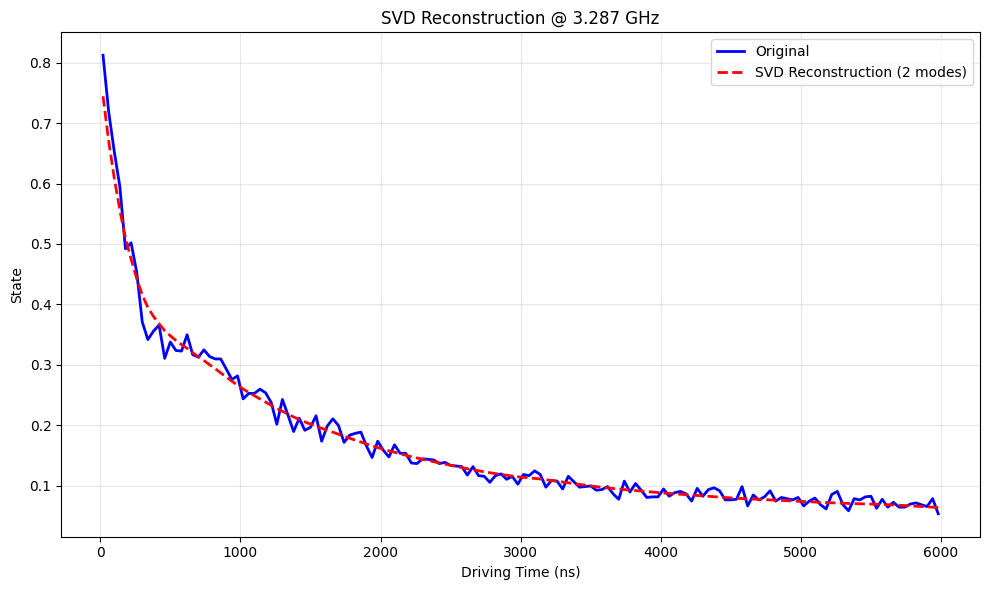

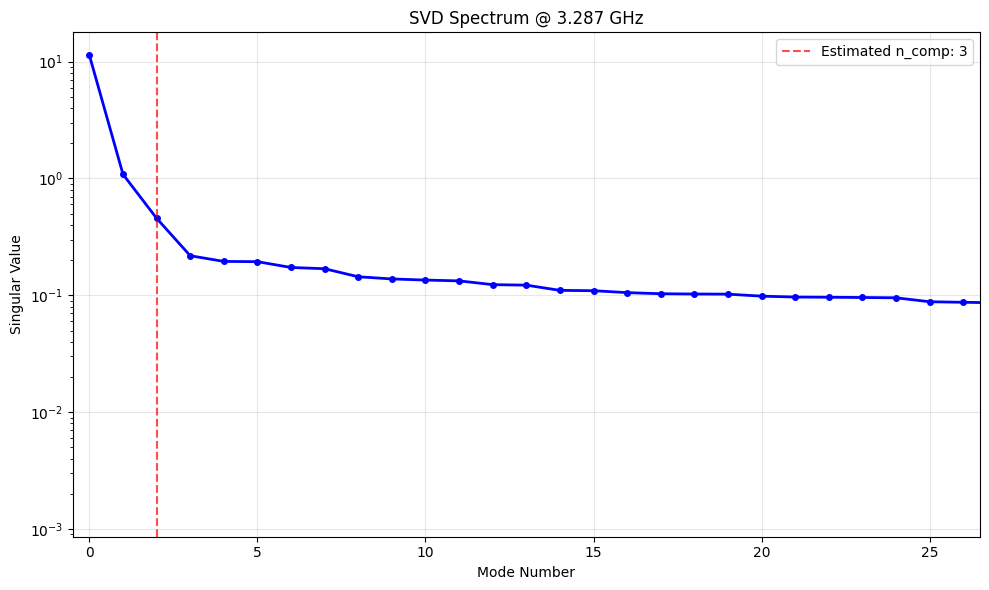

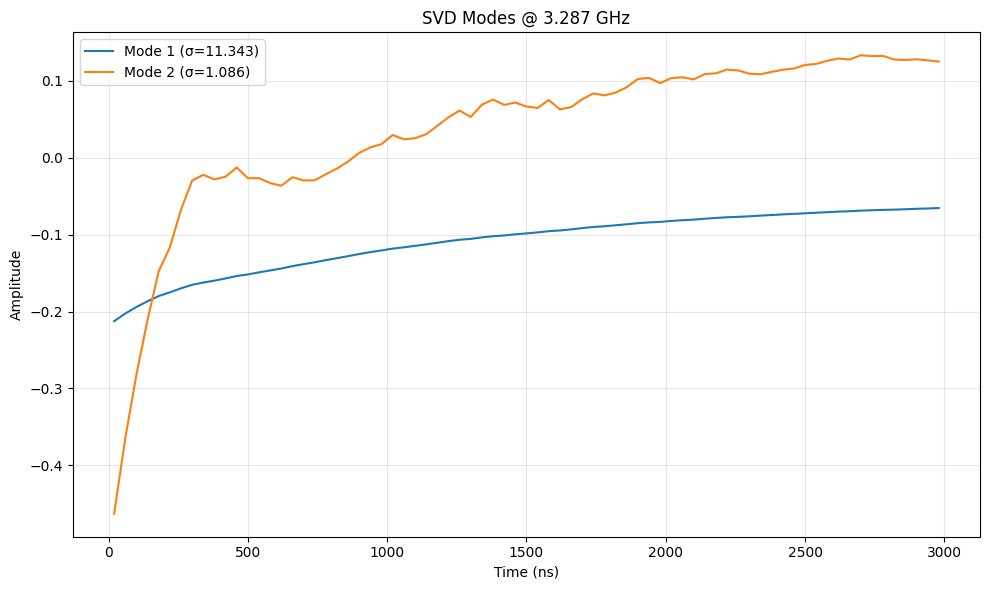

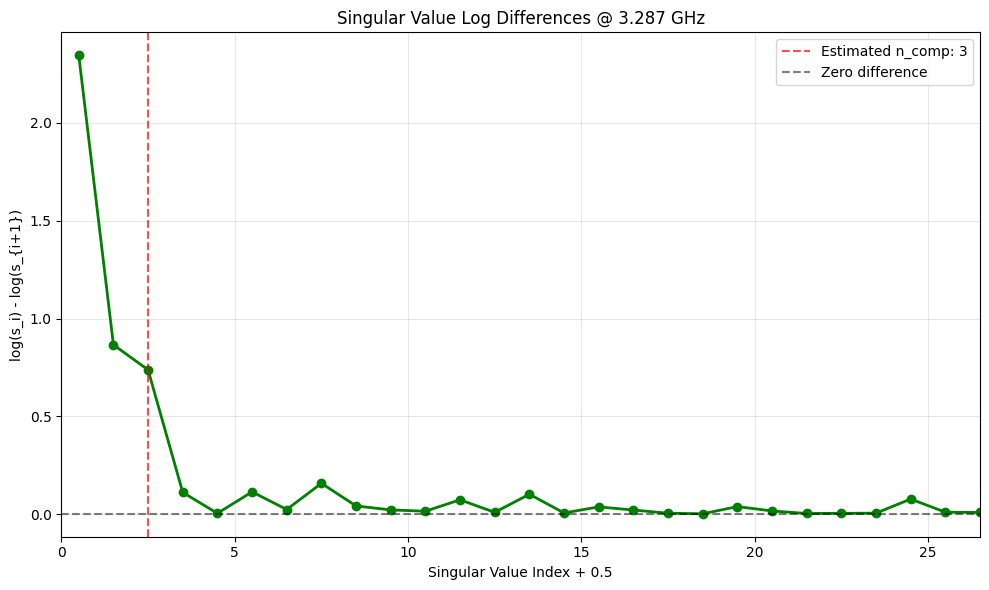

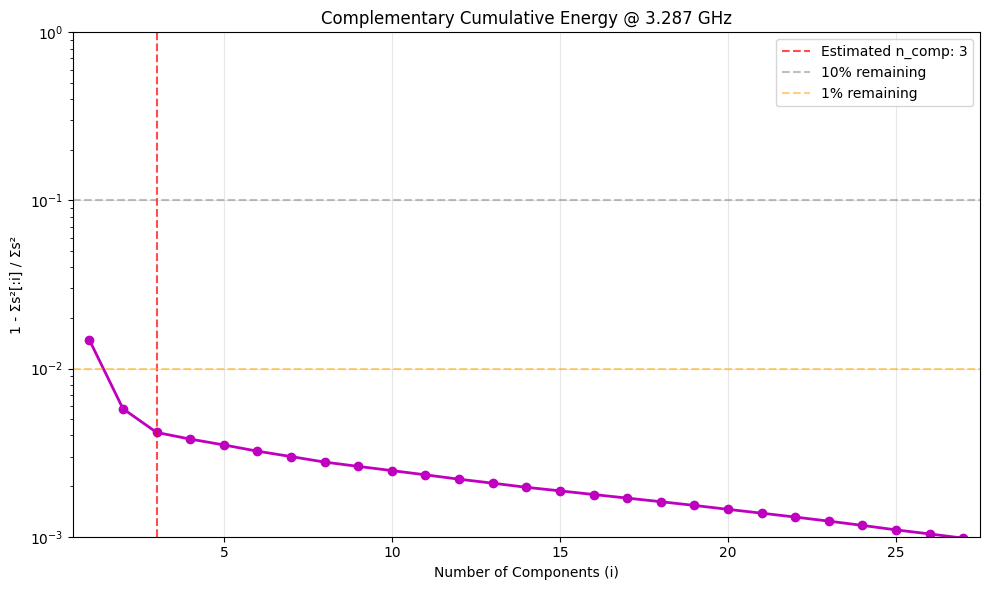

Processed frequency: 3.287 GHz
  Hankel matrix size: (75, 76)
  Number of singular values: 75
  Dominant singular values: [11.3427741   1.08589516  0.45653094  0.21823229  0.19511129]
  Energy in first mode: 98.5%
  Energy in first 3 modes: 99.6%
  X-axis limit (99% energy): 27 modes


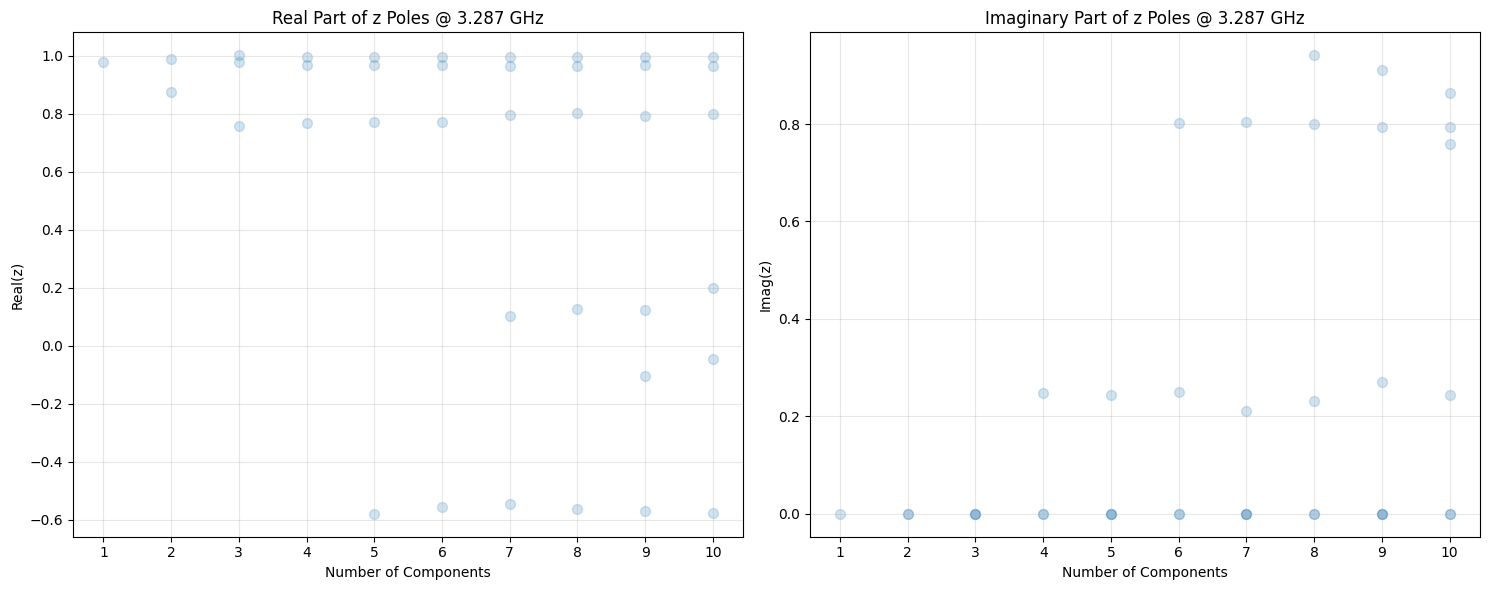


  === Complex Pole Analysis (Component Sweep) ===

  n_components = 1:
    Number of extracted poles: 1
      Pole 1: z = 0.9792+0.0000j
        Frequency: 0.000e+00 Hz
        Time constant: 1903.7 ns
        Oscillating: False

  n_components = 2:
    Number of extracted poles: 2
      Pole 1: z = 0.8739+0.0000j
        Frequency: 0.000e+00 Hz
        Time constant: 296.9 ns
        Oscillating: False
      Pole 2: z = 0.9884+0.0000j
        Frequency: 0.000e+00 Hz
        Time constant: 3419.3 ns
        Oscillating: False

  n_components = 3:
    Number of extracted poles: 3
      Pole 1: z = 0.7580+0.0000j
        Frequency: 0.000e+00 Hz
        Time constant: 144.4 ns
        Oscillating: False
      Pole 2: z = 0.9779+0.0000j
        Frequency: 0.000e+00 Hz
        Time constant: 1789.2 ns
        Oscillating: False
      Pole 3: z = 1.0023+0.0000j
        Frequency: 0.000e+00 Hz
        Time constant: ∞ (no decay)
        Oscillating: False

  n_components = 4:
    Number of e

In [14]:
# SVD and Hankel Matrix Analysis using HankelSVDAnalyzer Class
from hankel_svd_analyzer import HankelSVDAnalyzer
import importlib
import hankel_svd_analyzer
importlib.reload(hankel_svd_analyzer)
from hankel_svd_analyzer import HankelSVDAnalyzer

if ds is not None and 'qubit_data' in locals():
    print("Performing SVD and Hankel Matrix analysis using HankelSVDAnalyzer class...")
    
    # Use the same target frequencies as defined in cell 9
    target_frequencies = [3.1515e8]  # Modify this list as needed
    
    for i, sq_data in enumerate(qubit_data):
        # Select index 2 from basis coordinate if it exists
        if 'basis' in sq_data.coords:
            sq_data = sq_data.isel(basis=2)
            print(f"Selected basis index 2 from coordinate")
        
        try:
            qubit_name = sq_data["qubit"].values.item() if "qubit" in sq_data else f"Dataset_{i}"
            print(f"\nAnalyzing qubit {i}: {qubit_name}")
        except:
            print(f"\nAnalyzing dataset {i}")
        
        # Get driving_time and driving_frequency arrays
        driving_time = sq_data.coords["driving_time"].values
        driving_freq = sq_data.coords["driving_frequency"].values
        
        # Analyze each target frequency
        for j, freq in enumerate(target_frequencies):
            # Find closest frequency in the data
            freq_idx = np.argmin(np.abs(driving_freq - freq))
            actual_freq = driving_freq[freq_idx]
            
            # Extract state data for this frequency
            state_data = sq_data["state"].isel(driving_frequency=freq_idx).values
            
            # === Use HankelSVDAnalyzer Class ===
            # Initialize the analyzer
            dt_ns = driving_time[1] - driving_time[0]  # Time step in nanoseconds
            analyzer = HankelSVDAnalyzer(dt_ns*1e-9)
            
            # Perform SVD analysis
            U, s, Vt = analyzer.analyze_signal(state_data)
            
            # Reconstruct signal using first few modes
            n_modes = min(2, len(s))
            reconstructed_signal = analyzer.reconstruct_signal(n_modes)
            
            # Get estimated n_components for vertical line annotations
            estimated_n_components = analyzer.estimate_n_components('energy', threshold=0.999)
            
            # Calculate x-axis limit based on 99% energy threshold
            cumulative_energy = np.cumsum(s**2) / np.sum(s**2)
            max_mode_99 = np.where(cumulative_energy < 0.999)[0]
            if len(max_mode_99) > 0:
                x_limit_max = max_mode_99[-1] + 2  # +2 for better visualization
            else:
                x_limit_max = min(10, len(s))  # fallback limit
            
            # Plot 1: SVD Reconstruction
            plt.figure(figsize=(10, 6))
            plt.plot(driving_time, state_data, 'b-', linewidth=2, label='Original')
            plt.plot(driving_time, reconstructed_signal, 'r--', linewidth=2, label=f'SVD Reconstruction ({n_modes} modes)')
            plt.xlabel('Driving Time (ns)')
            plt.ylabel('State')
            plt.title(f'SVD Reconstruction @ {actual_freq/1e8:.3f} GHz')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
            
            # Plot 2: Singular Values
            plt.figure(figsize=(10, 6))
            plt.semilogy(s, 'bo-', markersize=4, linewidth=2)
            plt.axvline(x=estimated_n_components-1, color='red', linestyle='--', alpha=0.7, 
                       label=f'Estimated n_comp: {estimated_n_components}')
            plt.xlim(-0.5, x_limit_max - 0.5)
            plt.xlabel('Mode Number')
            plt.ylabel('Singular Value')
            plt.title(f'SVD Spectrum @ {actual_freq/1e8:.3f} GHz')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
            
            # Plot 3: SVD Modes
            plt.figure(figsize=(10, 6))
            n_modes_plot = n_modes
            time_hankel = driving_time[:U.shape[0]]  # Time for Hankel matrix rows
            
            for mode in range(n_modes_plot):
                plt.plot(time_hankel, U[:, mode], label=f'Mode {mode+1} (σ={s[mode]:.3f})', linewidth=1.5)
            
            plt.xlabel('Time (ns)')
            plt.ylabel('Amplitude')
            plt.title(f'SVD Modes @ {actual_freq/1e8:.3f} GHz')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
            
            # Plot 4: Singular Value Differences
            plt.figure(figsize=(10, 6))
            if len(s) > 1:
                # Calculate log differences: log(s_i) - log(s_i+1)
                log_s_diff = np.log(s[:-1]) - np.log(s[1:])
                x_indices = np.arange(len(log_s_diff)) + 0.5
                
                plt.plot(x_indices, log_s_diff, 'go-', markersize=6, linewidth=2)
                plt.axvline(x=estimated_n_components-0.5, color='red', linestyle='--', alpha=0.7, 
                           label=f'Estimated n_comp: {estimated_n_components}')
                plt.xlim(0, x_limit_max - 0.5)
                plt.xlabel('Singular Value Index + 0.5')
                plt.ylabel('log(s_i) - log(s_{i+1})')
                plt.title(f'Singular Value Log Differences @ {actual_freq/1e8:.3f} GHz')
                plt.grid(True, alpha=0.3)
                
                # Add annotation for interpretation
                plt.axhline(y=0, color='black', linestyle='--', alpha=0.5, label='Zero difference')
                plt.legend()
            else:
                plt.text(0.5, 0.5, 'Not enough singular values\nfor difference calculation', 
                        transform=plt.gca().transAxes, ha='center', va='center', fontsize=12)
                plt.xlabel('Singular Value Index + 0.5')
                plt.ylabel('log(s_i) - log(s_{i+1})')
                plt.title(f'Singular Value Log Differences @ {actual_freq/1e8:.3f} GHz')
                plt.grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.show()
            
            # Plot 5: Complementary Cumulative Energy
            plt.figure(figsize=(10, 6))
            if len(s) > 0:
                # Calculate complementary cumulative energy: 1 - sum(s[:i]**2) / sum(s**2)
                total_energy = np.sum(s**2)
                i_values = np.arange(1, len(s) + 1)
                complementary_energy = []
                
                for i in i_values:
                    cumulative_energy = np.sum(s[:i]**2) / total_energy
                    complementary_energy.append(1 - cumulative_energy)
                
                plt.semilogy(i_values, complementary_energy, 'mo-', markersize=6, linewidth=2)
                plt.axvline(x=estimated_n_components, color='red', linestyle='--', alpha=0.7, 
                           label=f'Estimated n_comp: {estimated_n_components}')
                plt.xlim(0.5, x_limit_max + 0.5)
                plt.ylim(1e-3, 1)
                plt.xlabel('Number of Components (i)')
                plt.ylabel('1 - Σs²[:i] / Σs²')
                plt.title(f'Complementary Cumulative Energy @ {actual_freq/1e8:.3f} GHz')
                plt.grid(True, alpha=0.3)
                
                # Add horizontal lines for reference
                plt.axhline(y=0.1, color='gray', linestyle='--', alpha=0.5, label='10% remaining')
                plt.axhline(y=0.01, color='orange', linestyle='--', alpha=0.5, label='1% remaining')
                plt.legend()
            else:
                plt.text(0.5, 0.5, 'No singular values available', 
                        transform=plt.gca().transAxes, ha='center', va='center', fontsize=12)
                plt.xlabel('Number of Components (i)')
                plt.ylabel('1 - Σs²[:i] / Σs²')
                plt.title(f'Complementary Cumulative Energy @ {actual_freq/1e8:.3f} GHz')
                plt.grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.show()
            
            # Print analysis results using analyzer methods
            analysis_summary = analyzer.get_summary()
            print(f"Processed frequency: {actual_freq/1e8:.3f} GHz")
            print(f"  Hankel matrix size: {analysis_summary['hankel_size']}")
            print(f"  Number of singular values: {analysis_summary['n_singular_values']}")
            print(f"  Dominant singular values: {s[:min(5, len(s))]}")
            print(f"  Energy in first mode: {analysis_summary['energy_in_first_mode']:.1f}%")
            energy_first_3_modes = np.sum(s[:3]**2) / np.sum(s**2) * 100
            print(f"  Energy in first 3 modes: {energy_first_3_modes:.1f}%")
            print(f"  X-axis limit (99% energy): {x_limit_max} modes")
            
            # === Extract Complex Poles ===
            # Sweep analysis with n_component_max = 5
            n_component_max = 10
            sweep_results = analyzer.sweep_components(min(n_component_max, len(s)))
            
            # Plot z poles as function of n_components
            if sweep_results:
                # Collect z poles for plotting
                n_components_list = []
                z_real_list = []
                z_imag_list = []
                
                for n_comp, poles in sweep_results.items():
                    for pole in poles:
                        n_components_list.append(n_comp)
                        z_real_list.append(pole['z_pole'].real)
                        z_imag_list.append(pole['z_pole'].imag)
                
                if n_components_list:  # Only plot if we have data
                    # Plot Real and Imaginary parts
                    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
                    
                    # Real part
                    ax1.scatter(n_components_list, z_real_list, alpha=0.2, s=50)
                    ax1.set_xlabel('Number of Components')
                    ax1.set_ylabel('Real(z)')
                    ax1.set_title(f'Real Part of z Poles @ {actual_freq/1e8:.3f} GHz')
                    ax1.grid(True, alpha=0.3)
                    ax1.set_xticks(range(1, min(n_component_max, len(s))+1))
                    
                    # Imaginary part
                    ax2.scatter(n_components_list, z_imag_list, alpha=0.2, s=50)
                    ax2.set_xlabel('Number of Components')
                    ax2.set_ylabel('Imag(z)')
                    ax2.set_title(f'Imaginary Part of z Poles @ {actual_freq/1e8:.3f} GHz')
                    ax2.grid(True, alpha=0.3)
                    ax2.set_xticks(range(1, min(n_component_max, len(s))+1))
                    
                    plt.tight_layout()
                    plt.show()
            
            # Display detailed pole information for each n_components
            print(f"\n  === Complex Pole Analysis (Component Sweep) ===")
            if sweep_results:
                for n_comp, poles in sweep_results.items():
                    print(f"\n  n_components = {n_comp}:")
                    print(f"    Number of extracted poles: {len(poles)}")
                    if poles:
                        for idx, pole in enumerate(poles):
                            z = pole["z_pole"]
                            print(f"      Pole {idx+1}: z = {z:.4f}")
                            print(f"        Frequency: {pole['freq_hz']:.3e} Hz")
                            if np.isfinite(pole['time_constant']):
                                tau_ns = pole['time_constant'] * 1e9  # Convert to nanoseconds
                                print(f"        Time constant: {tau_ns:.1f} ns")
                            else:
                                print(f"        Time constant: ∞ (no decay)")
                            print(f"        Oscillating: {pole['is_oscillating']}")
                    else:
                        print("      No valid poles extracted")
            else:
                print(f"  No valid poles extracted for any n_components")
        
        # Additional analysis summary using analyzer
        if 'analysis_summary' in locals():
            print(f"\nSVD/Hankel Analysis Summary for Qubit {qubit_name}:")
            print(f"  Matrix rank (effective): {analysis_summary['effective_rank']}")
    
    print("\nSVD and Hankel matrix analysis complete!")